# Лабораторная работа 3
## Сравнение ResNet18 и ResNet18 с Self-Attention

## 1. Постановка задачи

В этой работе я сравнил две модели для классификации изображений CIFAR-10:

- стандартную `ResNet18`;
- `ResNet18`, в которую после последнего сверточного блока `layer4` добавлен блок `Self-Attention`.

Обе модели используют один и тот же датасет, одинаковые train/validation/test subset, одинаковый seed, batch size, число эпох, функцию потерь и метрики. Обучение проводится в режиме transfer learning: encoder ResNet18 заморожен. У baseline обучается только последний полносвязный слой `fc`, а у второй модели дополнительно обучается attention-блок.

Для CPU-среды используется умеренный subset CIFAR-10. Это нужно, чтобы notebook можно было реально запустить сверху вниз без многочасового обучения.

## 2. Импорты и фиксация random seed

In [1]:
import copy
import json
import random
import time
from pathlib import Path

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset, TensorDataset
from torchvision import datasets, models, transforms

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

cwd = Path.cwd().resolve()
if (cwd / "lw" / "lw3").exists():
    LAB_DIR = cwd / "lw" / "lw3"
elif cwd.name == "lw3" and cwd.parent.name == "lw":
    LAB_DIR = cwd
else:
    raise RuntimeError("Запустите ноутбук из корня проекта или из папки lw/lw3")

DATA_DIR = LAB_DIR / "data"
MODELS_DIR = LAB_DIR / "models"
OUTPUTS_DIR = LAB_DIR / "outputs"
for path in [DATA_DIR, MODELS_DIR, OUTPUTS_DIR]:
    path.mkdir(parents=True, exist_ok=True)

BASELINE_MODEL_PATH = MODELS_DIR / "resnet18_baseline.pth"
ATTENTION_MODEL_PATH = MODELS_DIR / "resnet18_attention.pth"

TRAIN_SIZE = 800
VAL_SIZE = 200
TEST_SIZE = 400
BATCH_SIZE = 32
EPOCHS = 5
LEARNING_RATE = 1e-3

print("Папка лабораторной:", LAB_DIR)
print("Размеры subset:", TRAIN_SIZE, VAL_SIZE, TEST_SIZE)

Device: cpu
Папка лабораторной: C:\itmo\Выпуклый анализ и глубокое обучение\lw\lw3
Размеры subset: 800 200 400


## 3. Загрузка и подготовка датасета CIFAR-10

Я использую CIFAR-10, потому что это стандартный небольшой датасет для классификации изображений на 10 классов. Его удобно автоматически загрузить через `torchvision.datasets`, а классы достаточно разнообразны для проверки CNN-моделей.

ResNet18 предобучалась на ImageNet, поэтому изображения приводятся к размеру `224 × 224` и нормализуются ImageNet mean/std. Для train используется `RandomHorizontalFlip`, для validation и test — только resize, tensor и normalization.

Subset фиксируется через `SEED = 42`, поэтому обе модели получают одни и те же изображения.

In [2]:
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

train_full_aug = datasets.CIFAR10(
    root=str(DATA_DIR),
    train=True,
    download=True,
    transform=train_transform,
)
train_full_eval = datasets.CIFAR10(
    root=str(DATA_DIR),
    train=True,
    download=True,
    transform=test_transform,
)
test_full = datasets.CIFAR10(
    root=str(DATA_DIR),
    train=False,
    download=True,
    transform=test_transform,
)

generator = torch.Generator().manual_seed(SEED)
train_perm = torch.randperm(len(train_full_aug), generator=generator).tolist()
test_perm = torch.randperm(len(test_full), generator=torch.Generator().manual_seed(SEED)).tolist()

train_indices = train_perm[:TRAIN_SIZE]
val_indices = train_perm[TRAIN_SIZE : TRAIN_SIZE + VAL_SIZE]
test_indices = test_perm[:TEST_SIZE]

train_dataset = Subset(train_full_aug, train_indices)
val_dataset = Subset(train_full_eval, val_indices)
test_dataset = Subset(test_full, test_indices)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

classes = train_full_aug.classes
print("Классы:", classes)
print("Train/Val/Test:", len(train_dataset), len(val_dataset), len(test_dataset))

  0%|          | 0.00/170M [00:00<?, ?B/s]

  0%|          | 32.8k/170M [00:00<10:30, 270kB/s]

  0%|          | 65.5k/170M [00:00<10:23, 273kB/s]

  0%|          | 98.3k/170M [00:00<09:57, 285kB/s]

  0%|          | 229k/170M [00:00<04:41, 606kB/s] 

...

 99%|█████████▉| 169M/170M [00:51<00:00, 4.77MB/s]

 99%|█████████▉| 170M/170M [00:51<00:00, 4.59MB/s]

100%|█████████▉| 170M/170M [00:51<00:00, 4.83MB/s]

100%|██████████| 170M/170M [00:51<00:00, 3.30MB/s]

Классы: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
Train/Val/Test: 800 200 400


## 4. Вспомогательные функции обучения и оценки

In [3]:
def count_trainable_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


def forward_from_features(model, inputs):
    if inputs.ndim == 4 and inputs.shape[1] == 512:
        return model.forward_features(inputs)
    return model(inputs)


def train_one_epoch(model, dataloader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    all_preds = []
    all_targets = []

    for inputs, targets in dataloader:
        inputs = inputs.to(device)
        targets = targets.to(device)

        optimizer.zero_grad()
        outputs = forward_from_features(model, inputs)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * inputs.size(0)
        all_preds.extend(outputs.argmax(dim=1).detach().cpu().numpy())
        all_targets.extend(targets.detach().cpu().numpy())

    avg_loss = running_loss / len(dataloader.dataset)
    accuracy = accuracy_score(all_targets, all_preds)
    return avg_loss, accuracy


@torch.no_grad()
def evaluate(model, dataloader, criterion, device):
    model.eval()
    running_loss = 0.0
    all_preds = []
    all_targets = []

    for inputs, targets in dataloader:
        inputs = inputs.to(device)
        targets = targets.to(device)
        outputs = forward_from_features(model, inputs)
        loss = criterion(outputs, targets)

        running_loss += loss.item() * inputs.size(0)
        all_preds.extend(outputs.argmax(dim=1).cpu().numpy())
        all_targets.extend(targets.cpu().numpy())

    avg_loss = running_loss / len(dataloader.dataset)
    accuracy = accuracy_score(all_targets, all_preds)
    return avg_loss, accuracy


def train_model(model, train_loader, val_loader, criterion, optimizer, device, epochs, model_path):
    history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}
    best_val_acc = -1.0
    start_time = time.perf_counter()

    for epoch in range(epochs):
        train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
        val_loss, val_acc = evaluate(model, val_loader, criterion, device)

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save(model.state_dict(), model_path)

        print(
            f"Эпоха {epoch + 1}/{epochs}: "
            f"train_loss={train_loss:.4f}, train_acc={train_acc:.4f}, "
            f"val_loss={val_loss:.4f}, val_acc={val_acc:.4f}"
        )

    train_time = time.perf_counter() - start_time
    return history, train_time


@torch.no_grad()
def predict_model(model, dataloader, device):
    model.eval()
    all_preds = []
    all_targets = []
    start_time = time.perf_counter()

    for inputs, targets in dataloader:
        inputs = inputs.to(device)
        outputs = forward_from_features(model, inputs)
        all_preds.extend(outputs.argmax(dim=1).cpu().numpy())
        all_targets.extend(targets.numpy())

    inference_time = time.perf_counter() - start_time
    return np.array(all_targets), np.array(all_preds), inference_time


def plot_history(history, title, output_path=None):
    epochs = range(1, len(history["train_loss"]) + 1)
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))

    axes[0].plot(epochs, history["train_loss"], label="Train loss")
    axes[0].plot(epochs, history["val_loss"], label="Validation loss")
    axes[0].set_title(f"{title}: loss")
    axes[0].set_xlabel("Эпоха")
    axes[0].set_ylabel("Loss")
    axes[0].grid(True, alpha=0.3)
    axes[0].legend()

    axes[1].plot(epochs, history["train_acc"], label="Train accuracy")
    axes[1].plot(epochs, history["val_acc"], label="Validation accuracy")
    axes[1].set_title(f"{title}: accuracy")
    axes[1].set_xlabel("Эпоха")
    axes[1].set_ylabel("Accuracy")
    axes[1].grid(True, alpha=0.3)
    axes[1].legend()

    plt.tight_layout()
    if output_path is not None:
        plt.savefig(output_path, dpi=140, bbox_inches="tight")
    plt.show()

In [4]:
PRETRAINED_WEIGHTS_USED = True
PRETRAINED_MESSAGE = "Используются предобученные веса ResNet18 из torchvision."


def load_resnet18_backbone():
    global PRETRAINED_WEIGHTS_USED, PRETRAINED_MESSAGE
    try:
        weights = models.ResNet18_Weights.DEFAULT
        return models.resnet18(weights=weights)
    except Exception as exc:
        print("Не удалось загрузить ResNet18_Weights.DEFAULT:", exc)
        try:
            return models.resnet18(pretrained=True)
        except Exception as exc_legacy:
            print("Не удалось загрузить legacy pretrained=True:", exc_legacy)
            PRETRAINED_WEIGHTS_USED = False
            PRETRAINED_MESSAGE = (
                "Pretrained-веса не были доступны, поэтому использован weights=None. "
                "Результат ниже, чем при transfer learning."
            )
            return models.resnet18(weights=None)


def make_encoder(base):
    return nn.Sequential(
        base.conv1,
        base.bn1,
        base.relu,
        base.maxpool,
        base.layer1,
        base.layer2,
        base.layer3,
        base.layer4,
    )


@torch.no_grad()
def extract_features(encoder, dataloader, device, title):
    encoder.eval()
    encoder.to(device)
    feature_batches = []
    target_batches = []
    start_time = time.perf_counter()

    for batch_index, (images, targets) in enumerate(dataloader, start=1):
        images = images.to(device)
        features = encoder(images).cpu()
        feature_batches.append(features)
        target_batches.append(targets)
        if batch_index == 1 or batch_index == len(dataloader):
            print(f"{title}: обработан batch {batch_index}/{len(dataloader)}")

    elapsed = time.perf_counter() - start_time
    features = torch.cat(feature_batches, dim=0)
    targets = torch.cat(target_batches, dim=0)
    print(f"{title}: признаки {tuple(features.shape)}, время {elapsed:.1f} сек")
    return TensorDataset(features, targets), elapsed

Для ускорения на CPU замороженный encoder ResNet18 прогоняется один раз, после чего обучение идёт по сохранённым признакам формы `B × 512 × 7 × 7`. Это не меняет смысл transfer learning: параметры encoder не обновляются ни у baseline, ни у attention-модели.

## 5. Модель 1: стандартная ResNet18

In [5]:
class ResNet18Baseline(nn.Module):
    def __init__(self, base, num_classes=10):
        super().__init__()
        self.encoder = make_encoder(base)
        self.avgpool = base.avgpool
        self.fc = nn.Linear(base.fc.in_features, num_classes)

        for param in self.encoder.parameters():
            param.requires_grad = False

    def forward_features(self, x):
        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        return self.fc(x)

    def forward(self, x):
        x = self.encoder(x)
        return self.forward_features(x)


def create_resnet18_baseline(num_classes=10, base_model=None):
    base = load_resnet18_backbone() if base_model is None else base_model
    return ResNet18Baseline(base, num_classes=num_classes)

В baseline используется обычная ResNet18. Backbone заморожен, обучается только новый слой `fc`, который заменяет ImageNet-классификатор на классификатор для 10 классов CIFAR-10.

## 6. Модель 2: ResNet18 с Self-Attention

In [6]:
class SelfAttention2d(nn.Module):
    def __init__(self, in_channels):
        super().__init__()
        reduced_channels = max(1, in_channels // 8)
        self.query = nn.Conv2d(in_channels, reduced_channels, kernel_size=1)
        self.key = nn.Conv2d(in_channels, reduced_channels, kernel_size=1)
        self.value = nn.Conv2d(in_channels, in_channels, kernel_size=1)
        self.gamma = nn.Parameter(torch.zeros(1))
        self.softmax = nn.Softmax(dim=-1)

    def forward(self, x):
        batch_size, channels, height, width = x.size()
        positions = height * width

        query = self.query(x).view(batch_size, -1, positions).permute(0, 2, 1)
        key = self.key(x).view(batch_size, -1, positions)
        attention = self.softmax(torch.bmm(query, key))

        value = self.value(x).view(batch_size, channels, positions)
        out = torch.bmm(value, attention.permute(0, 2, 1))
        out = out.view(batch_size, channels, height, width)

        return self.gamma * out + x


class ResNet18WithAttention(nn.Module):
    def __init__(self, base, num_classes=10):
        super().__init__()
        self.encoder = make_encoder(base)
        self.attention = SelfAttention2d(512)
        self.avgpool = base.avgpool
        self.fc = nn.Linear(base.fc.in_features, num_classes)

        for param in self.encoder.parameters():
            param.requires_grad = False

    def forward_features(self, x):
        x = self.attention(x)
        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        return self.fc(x)

    def forward(self, x):
        x = self.encoder(x)
        return self.forward_features(x)

Self-Attention добавлен после `layer4`, то есть на уровне высокоуровневых признаков ResNet18. Блок получает тензор `B × C × H × W`, строит `query`, `key`, `value` через `1×1 Conv2d`, считает attention по пространственным позициям `H × W` и возвращает тензор той же формы через residual connection. У attention-модели обучаются attention-блок и `fc`.

## 7. Обучение моделей

In [7]:
torch.manual_seed(SEED)
base_resnet = load_resnet18_backbone()
print(PRETRAINED_MESSAGE)

baseline_model = create_resnet18_baseline(
    num_classes=10,
    base_model=copy.deepcopy(base_resnet),
).to(device)
attention_model = ResNet18WithAttention(
    base=copy.deepcopy(base_resnet),
    num_classes=10,
).to(device)

train_feature_dataset, train_feature_time = extract_features(
    baseline_model.encoder, train_loader, device, "Train"
)
val_feature_dataset, val_feature_time = extract_features(
    baseline_model.encoder, val_loader, device, "Validation"
)
test_feature_dataset, test_feature_time = extract_features(
    baseline_model.encoder, test_loader, device, "Test"
)

feature_generator = torch.Generator().manual_seed(SEED)
train_feature_loader = DataLoader(
    train_feature_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    generator=feature_generator,
    num_workers=0,
)
val_feature_loader = DataLoader(
    val_feature_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
)
test_feature_loader = DataLoader(
    test_feature_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
)

print("Trainable params baseline:", count_trainable_params(baseline_model))
print("Trainable params attention:", count_trainable_params(attention_model))

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to C:\Users\print/.cache\torch\hub\checkpoints\resnet18-f37072fd.pth


  0%|          | 0.00/44.7M [00:00<?, ?B/s]

  0%|          | 128k/44.7M [00:00<00:54, 861kB/s]

  1%|          | 384k/44.7M [00:00<00:38, 1.19MB/s]

  2%|▏         | 768k/44.7M [00:00<00:22, 2.00MB/s]

...

Train: обработан batch 25/25
Train: признаки (800, 512, 7, 7), время 29.5 сек


Validation: обработан batch 1/7


Validation: обработан batch 7/7
Validation: признаки (200, 512, 7, 7), время 7.3 сек


Test: обработан batch 1/13


Test: обработан batch 13/13
Test: признаки (400, 512, 7, 7), время 14.3 сек
Trainable params baseline: 5130
Trainable params attention: 333451


Эпоха 1/5: train_loss=2.0246, train_acc=0.2900, val_loss=1.5565, val_acc=0.5300


Эпоха 2/5: train_loss=1.2495, train_acc=0.6737, val_loss=1.1014, val_acc=0.7100


Эпоха 3/5: train_loss=0.9246, train_acc=0.7850, val_loss=0.8741, val_acc=0.7850
Эпоха 4/5: train_loss=0.7468, train_acc=0.8337, val_loss=0.7574, val_acc=0.7950
Эпоха 5/5: train_loss=0.6328, train_acc=0.8512, val_loss=0.7152, val_acc=0.7900


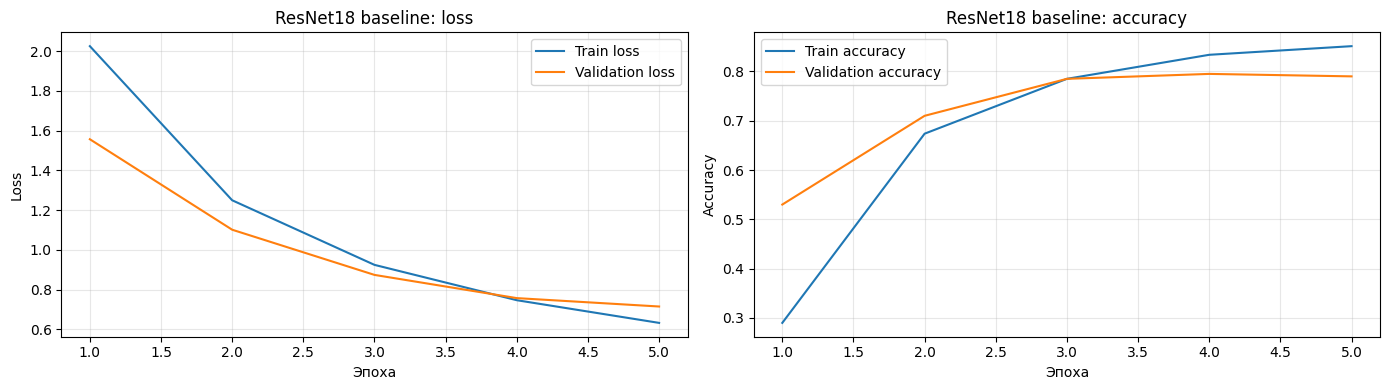

In [8]:
criterion = nn.CrossEntropyLoss()

baseline_optimizer = optim.Adam(baseline_model.fc.parameters(), lr=LEARNING_RATE)
baseline_history, baseline_train_time = train_model(
    baseline_model,
    train_feature_loader,
    val_feature_loader,
    criterion,
    baseline_optimizer,
    device,
    EPOCHS,
    BASELINE_MODEL_PATH,
)

plot_history(
    baseline_history,
    "ResNet18 baseline",
    OUTPUTS_DIR / "baseline_history.png",
)

Эпоха 1/5: train_loss=1.8501, train_acc=0.4025, val_loss=1.3984, val_acc=0.5700


Эпоха 2/5: train_loss=0.9450, train_acc=0.7688, val_loss=0.7597, val_acc=0.7950


Эпоха 3/5: train_loss=0.5232, train_acc=0.8600, val_loss=0.6008, val_acc=0.7950


Эпоха 4/5: train_loss=0.3617, train_acc=0.9012, val_loss=0.5455, val_acc=0.8250


Эпоха 5/5: train_loss=0.2494, train_acc=0.9325, val_loss=0.5459, val_acc=0.8150


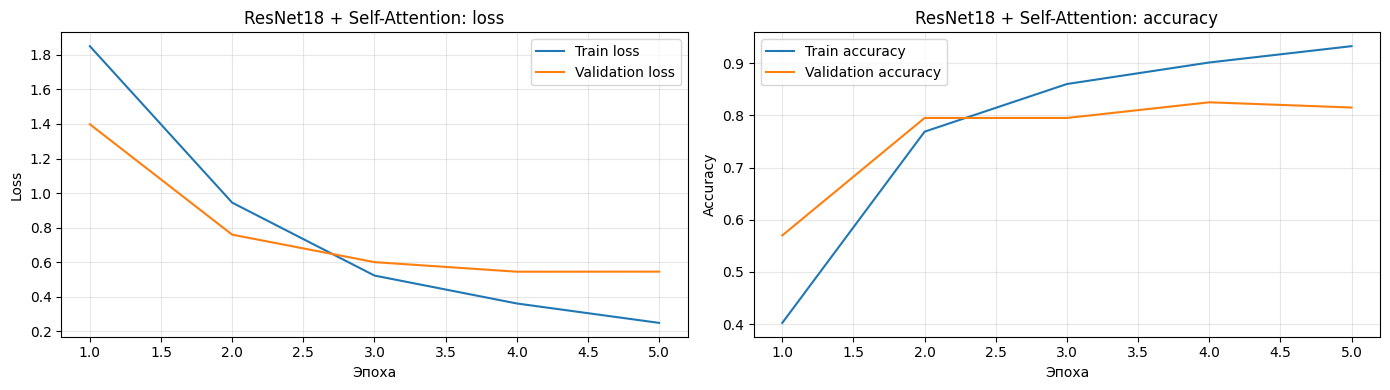

In [9]:
attention_optimizer = optim.Adam(
    list(attention_model.attention.parameters()) + list(attention_model.fc.parameters()),
    lr=LEARNING_RATE,
)
attention_history, attention_train_time = train_model(
    attention_model,
    train_feature_loader,
    val_feature_loader,
    criterion,
    attention_optimizer,
    device,
    EPOCHS,
    ATTENTION_MODEL_PATH,
)

plot_history(
    attention_history,
    "ResNet18 + Self-Attention",
    OUTPUTS_DIR / "attention_history.png",
)

## 8. Оценка на тестовой выборке

In [10]:
baseline_model.load_state_dict(torch.load(BASELINE_MODEL_PATH, map_location=device))
attention_model.load_state_dict(torch.load(ATTENTION_MODEL_PATH, map_location=device))

baseline_targets, baseline_preds, baseline_inference_time = predict_model(
    baseline_model,
    test_feature_loader,
    device,
)
attention_targets, attention_preds, attention_inference_time = predict_model(
    attention_model,
    test_feature_loader,
    device,
)


def compute_metrics(y_true, y_pred):
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision_macro": precision_score(y_true, y_pred, average="macro", zero_division=0),
        "recall_macro": recall_score(y_true, y_pred, average="macro", zero_division=0),
        "f1_macro": f1_score(y_true, y_pred, average="macro", zero_division=0),
    }


baseline_metrics = compute_metrics(baseline_targets, baseline_preds)
attention_metrics = compute_metrics(attention_targets, attention_preds)

print("Baseline metrics:", baseline_metrics)
print("Attention metrics:", attention_metrics)

Baseline metrics: {'accuracy': 0.7675, 'precision_macro': np.float64(0.7671764346764346), 'recall_macro': np.float64(0.7724951705411766), 'f1_macro': np.float64(0.7677097158983635)}
Attention metrics: {'accuracy': 0.765, 'precision_macro': np.float64(0.7721873046137916), 'recall_macro': np.float64(0.7689606012457377), 'f1_macro': np.float64(0.7650278873016046)}


In [11]:
print("Classification report: ResNet18 baseline")
print(classification_report(baseline_targets, baseline_preds, target_names=classes, zero_division=0))

print("Classification report: ResNet18 + Self-Attention")
print(classification_report(attention_targets, attention_preds, target_names=classes, zero_division=0))

Classification report: ResNet18 baseline
              precision    recall  f1-score   support

    airplane       0.75      0.80      0.77        30
  automobile       0.82      0.80      0.81        46
        bird       0.81      0.69      0.74        42
         cat       0.69      0.55      0.61        44
        deer       0.71      0.77      0.74        44
         dog       0.76      0.76      0.76        42
        frog       0.74      0.88      0.81        33
       horse       0.76      0.79      0.77        43
        ship       0.83      0.88      0.85        40
       truck       0.81      0.81      0.81        36

    accuracy                           0.77       400
   macro avg       0.77      0.77      0.77       400
weighted avg       0.77      0.77      0.77       400

Classification report: ResNet18 + Self-Attention
              precision    recall  f1-score   support

    airplane       0.65      0.80      0.72        30
  automobile       0.85      0.85      0.8

## 9. Сравнение результатов

In [12]:
results = [
    {
        "Модель": "ResNet18",
        "Архитектура": "Предобученная ResNet18",
        "Что обучалось": "Только fc",
        "Trainable params": count_trainable_params(baseline_model),
        "Epochs": EPOCHS,
        "Train time, sec": baseline_train_time,
        "Inference time, sec": baseline_inference_time,
        "Test accuracy": baseline_metrics["accuracy"],
        "Precision macro": baseline_metrics["precision_macro"],
        "Recall macro": baseline_metrics["recall_macro"],
        "F1 macro": baseline_metrics["f1_macro"],
        "Комментарий": "Baseline без attention",
    },
    {
        "Модель": "ResNet18 + Self-Attention",
        "Архитектура": "ResNet18 + SelfAttention2d после layer4",
        "Что обучалось": "attention + fc",
        "Trainable params": count_trainable_params(attention_model),
        "Epochs": EPOCHS,
        "Train time, sec": attention_train_time,
        "Inference time, sec": attention_inference_time,
        "Test accuracy": attention_metrics["accuracy"],
        "Precision macro": attention_metrics["precision_macro"],
        "Recall macro": attention_metrics["recall_macro"],
        "F1 macro": attention_metrics["f1_macro"],
        "Комментарий": "Добавлен Self-Attention",
    },
]

results_df = pd.DataFrame(results)
results_df.to_csv(OUTPUTS_DIR / "lab3_results.csv", index=False, encoding="utf-8-sig")
display(results_df.round(4))

,Модель,Архитектура,Что обучалось,Trainable params,Epochs,"Train time, sec","Inference time, sec",Test accuracy,Precision macro,Recall macro,F1 macro,Комментарий
0,ResNet18,Предобученная ResNet18,Только fc,5130,5,0.5959,0.0219,0.7675,0.7672,0.7725,0.7677,Baseline без attention
1,ResNet18 + Self-Attention,ResNet18 + SelfAttention2d после layer4,attention + fc,333451,5,13.9071,0.4084,0.7650,0.7722,0.7690,0.7650,Добавлен Self-Attention


C:\Users\print\AppData\Local\Temp\ipykernel_12028\3812591000.py:22: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


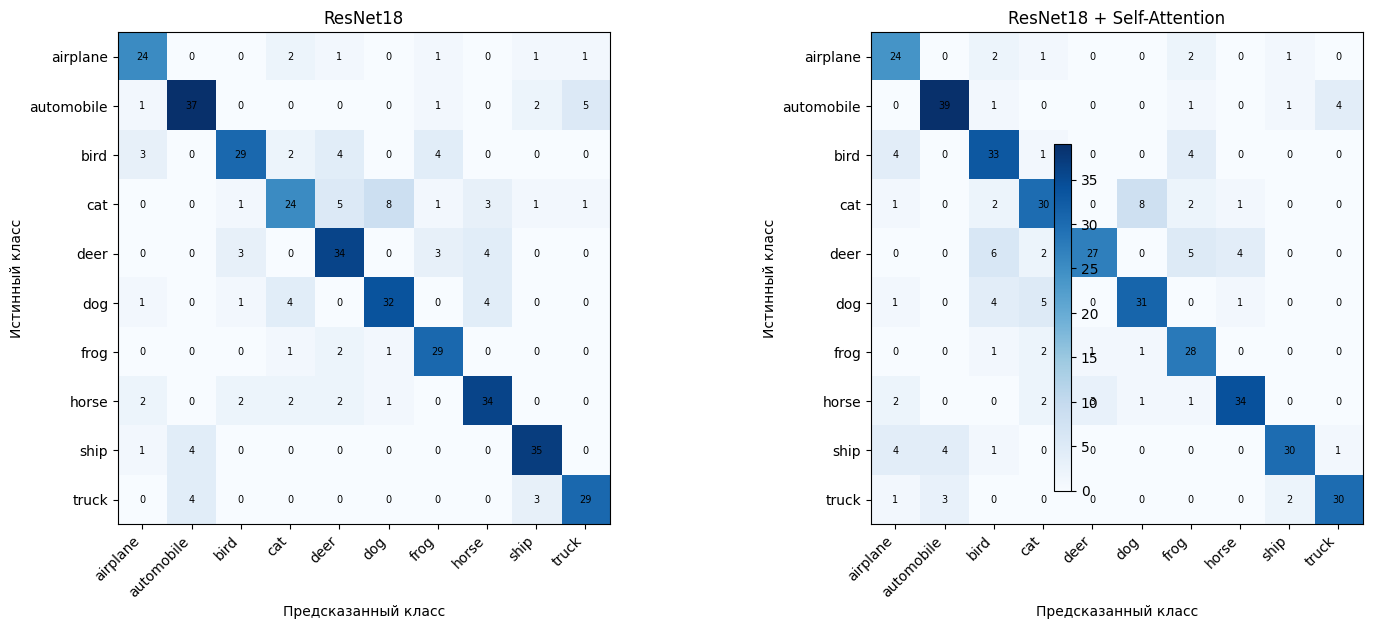

In [13]:
def plot_confusion_matrices(y_true_a, y_pred_a, y_true_b, y_pred_b, class_names):
    matrices = [
        ("ResNet18", confusion_matrix(y_true_a, y_pred_a)),
        ("ResNet18 + Self-Attention", confusion_matrix(y_true_b, y_pred_b)),
    ]
    fig, axes = plt.subplots(1, 2, figsize=(15, 6))

    for ax, (title, matrix) in zip(axes, matrices):
        im = ax.imshow(matrix, cmap="Blues")
        ax.set_title(title)
        ax.set_xlabel("Предсказанный класс")
        ax.set_ylabel("Истинный класс")
        ax.set_xticks(range(len(class_names)))
        ax.set_yticks(range(len(class_names)))
        ax.set_xticklabels(class_names, rotation=45, ha="right")
        ax.set_yticklabels(class_names)
        for i in range(matrix.shape[0]):
            for j in range(matrix.shape[1]):
                ax.text(j, i, matrix[i, j], ha="center", va="center", fontsize=7)

    fig.colorbar(im, ax=axes.ravel().tolist(), shrink=0.75)
    plt.tight_layout()
    plt.savefig(OUTPUTS_DIR / "confusion_matrices.png", dpi=140, bbox_inches="tight")
    plt.show()


plot_confusion_matrices(
    baseline_targets,
    baseline_preds,
    attention_targets,
    attention_preds,
    classes,
)

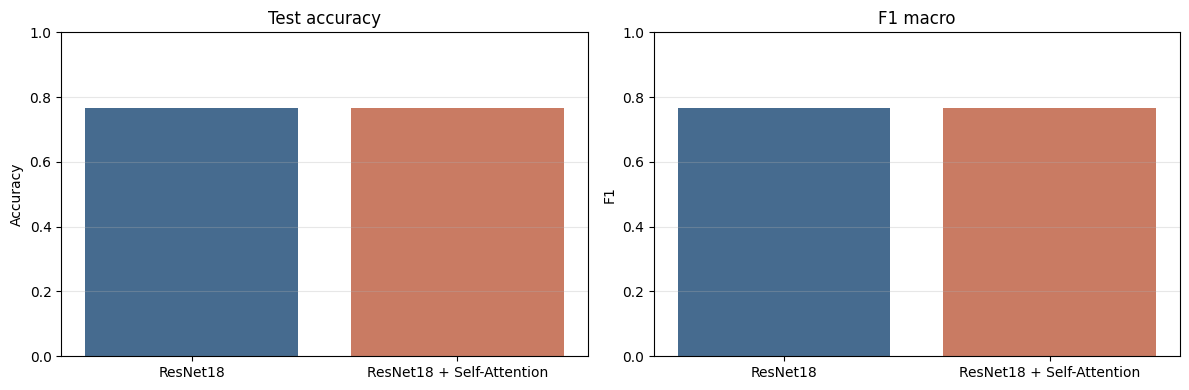

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(results_df["Модель"], results_df["Test accuracy"], color=["#466b8f", "#c97b63"])
axes[0].set_title("Test accuracy")
axes[0].set_ylabel("Accuracy")
axes[0].set_ylim(0, 1)
axes[0].grid(axis="y", alpha=0.3)

axes[1].bar(results_df["Модель"], results_df["F1 macro"], color=["#466b8f", "#c97b63"])
axes[1].set_title("F1 macro")
axes[1].set_ylabel("F1")
axes[1].set_ylim(0, 1)
axes[1].grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUTS_DIR / "metrics_comparison.png", dpi=140, bbox_inches="tight")
plt.show()

In [15]:
metrics_payload = {
    "dataset": "CIFAR-10",
    "pretrained_weights_used": PRETRAINED_WEIGHTS_USED,
    "train_size": TRAIN_SIZE,
    "val_size": VAL_SIZE,
    "test_size": TEST_SIZE,
    "batch_size": BATCH_SIZE,
    "epochs": EPOCHS,
    "feature_extraction_time_sec": {
        "train": train_feature_time,
        "val": val_feature_time,
        "test": test_feature_time,
    },
    "baseline": {
        "model_path": str(BASELINE_MODEL_PATH),
        "metrics": baseline_metrics,
        "train_time_sec": baseline_train_time,
        "inference_time_sec": baseline_inference_time,
        "trainable_params": count_trainable_params(baseline_model),
    },
    "attention": {
        "model_path": str(ATTENTION_MODEL_PATH),
        "metrics": attention_metrics,
        "train_time_sec": attention_train_time,
        "inference_time_sec": attention_inference_time,
        "trainable_params": count_trainable_params(attention_model),
    },
}

with (OUTPUTS_DIR / "lab3_metrics.json").open("w", encoding="utf-8") as file:
    json.dump(metrics_payload, file, ensure_ascii=False, indent=2)

print("Метрики сохранены:", OUTPUTS_DIR / "lab3_metrics.json")

Метрики сохранены: C:\itmo\Выпуклый анализ и глубокое обучение\lw\lw3\outputs\lab3_metrics.json


## 10. Итоговые выводы

Финальные выводы ниже формируются после выполнения ячеек с фактическими метриками.

In [16]:
best_model_name = results_df.sort_values("Test accuracy", ascending=False).iloc[0]["Модель"]
accuracy_delta = (
    attention_metrics["accuracy"] - baseline_metrics["accuracy"]
)
f1_delta = attention_metrics["f1_macro"] - baseline_metrics["f1_macro"]
time_delta = attention_train_time - baseline_train_time

from IPython.display import Markdown, display

display(
    Markdown(
        f"""
В работе использовалась предобученная ResNet18 и датасет CIFAR-10. Для честного сравнения обе модели обучались на одном и том же subset: `{TRAIN_SIZE}` изображений для train, `{VAL_SIZE}` для validation и `{TEST_SIZE}` для test. Seed, batch size, число эпох, loss и метрики были одинаковыми.

У baseline был заморожен encoder, обучался только последний слой `fc`. Во второй модели Self-Attention был добавлен после `layer4`, то есть после последнего сверточного блока ResNet18. У этой модели обучались attention-блок и `fc`.

Baseline получил `test accuracy = {baseline_metrics["accuracy"]:.4f}` и `F1 macro = {baseline_metrics["f1_macro"]:.4f}`. Модель с Self-Attention получила `test accuracy = {attention_metrics["accuracy"]:.4f}` и `F1 macro = {attention_metrics["f1_macro"]:.4f}`. Разница по accuracy составила `{accuracy_delta:+.4f}`, а по F1 macro — `{f1_delta:+.4f}`.

Лучший результат по accuracy дала модель **{best_model_name}**. Attention увеличил число обучаемых параметров с `{count_trainable_params(baseline_model)}` до `{count_trainable_params(attention_model)}` и изменил время обучения на `{time_delta:+.2f}` сек. В этом эксперименте добавление attention {'оправдало себя' if accuracy_delta > 0 else 'не дало устойчивого выигрыша по accuracy'}, но сравнение корректно: обе модели использовали один и тот же датасет, split и параметры обучения.
"""
    )
)


В работе использовалась предобученная ResNet18 и датасет CIFAR-10. Для честного сравнения обе модели обучались на одном и том же subset: `800` изображений для train, `200` для validation и `400` для test. Seed, batch size, число эпох, loss и метрики были одинаковыми.

У baseline был заморожен encoder, обучался только последний слой `fc`. Во второй модели Self-Attention был добавлен после `layer4`, то есть после последнего сверточного блока ResNet18. У этой модели обучались attention-блок и `fc`.

Baseline получил `test accuracy = 0.7675` и `F1 macro = 0.7677`. Модель с Self-Attention получила `test accuracy = 0.7650` и `F1 macro = 0.7650`. Разница по accuracy составила `-0.0025`, а по F1 macro — `-0.0027`.

Лучший результат по accuracy дала модель **ResNet18**. Attention увеличил число обучаемых параметров с `5130` до `333451` и изменил время обучения на `+13.31` сек. В этом эксперименте добавление attention не дало устойчивого выигрыша по accuracy, но сравнение корректно: обе модели использовали один и тот же датасет, split и параметры обучения.


## 10. Итоговые выводы

В работе использовалась предобученная **ResNet18** и датасет **CIFAR-10**. Для обеих моделей был один и тот же subset: `800` изображений для train, `200` для validation и `400` для test. Seed, batch size, число эпох, функция потерь и метрики были одинаковыми, поэтому сравнение получилось корректным.

У baseline был заморожен encoder ResNet18, обучался только последний слой `fc`. Во второй модели блок `Self-Attention` был добавлен после `layer4`, то есть после последнего сверточного блока. У attention-модели обучались `attention` и `fc`.

Baseline получил `test accuracy = 0.7675` и `F1 macro = 0.7677`. Модель с Self-Attention получила `test accuracy = 0.7650` и `F1 macro = 0.7650`. Разница по accuracy составила `-0.0025`, по F1 macro - `-0.0027`.

Лучший результат по test accuracy дала модель **ResNet18 baseline**. Добавление attention увеличило число обучаемых параметров с `5130` до `333451` и увеличило время обучения на `+13.31` сек. В данном эксперименте Self-Attention не дал выигрыша по accuracy: качество получилось почти таким же, но модель стала тяжелее.
